# Сессионное задание

In [ ]:
import warnings

warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import linear_sum_assignment
from scipy.signal import find_peaks
from scipy.stats import kurtosis
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import RobustScaler, StandardScaler
import umap.umap_ as umap

In [ ]:
# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
signal_df = pd.read_csv('Run200_Wave_0_1.txt', header=None)
print("Формат данных через Pandas:", signal_df.shape)

Формат данных через Pandas: (23479, 1)


Полный размер загруженной матрицы (без битых строк): (23479, 504)
Размерность матрицы сигналов для анализа: (23479, 500)


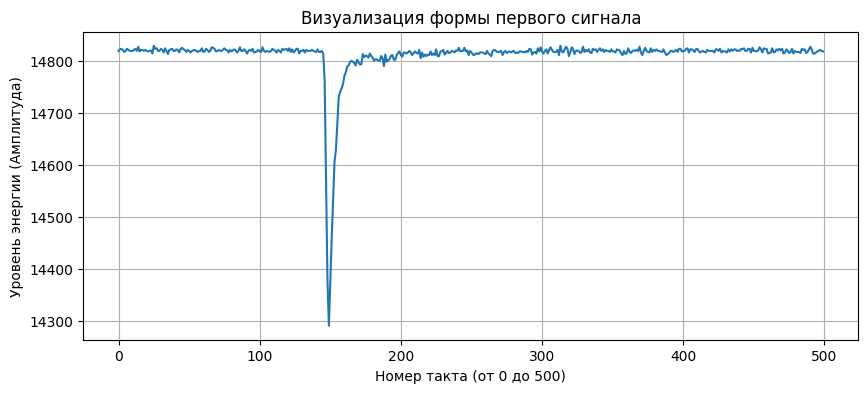

In [ ]:
# 1. Загружаем матрицу, автоматически пропуская строки неверной длины
raw_data = np.genfromtxt("Run200_Wave_0_1.txt", invalid_raise=False)
print(f"Полный размер загруженной матрицы (без битых строк): {raw_data.shape}")

# 2. Отделяем первые 4 колонки метаданных
metadata = raw_data[:, :4]

# 3. Отделяем 500 колонок, описывающих форму сигналов
signals = raw_data[:, 4:]
print(f"Размерность матрицы сигналов для анализа: {signals.shape}")

# 4. Визуализируем один любой сигнал (например, первый в списке)
plt.figure(figsize=(10, 4))
plt.plot(signals[0])
plt.title("Визуализация формы первого сигнала")
plt.xlabel("Номер такта (от 0 до 500)")
plt.ylabel("Уровень энергии (Амплитуда)")
plt.grid(True)
plt.show()

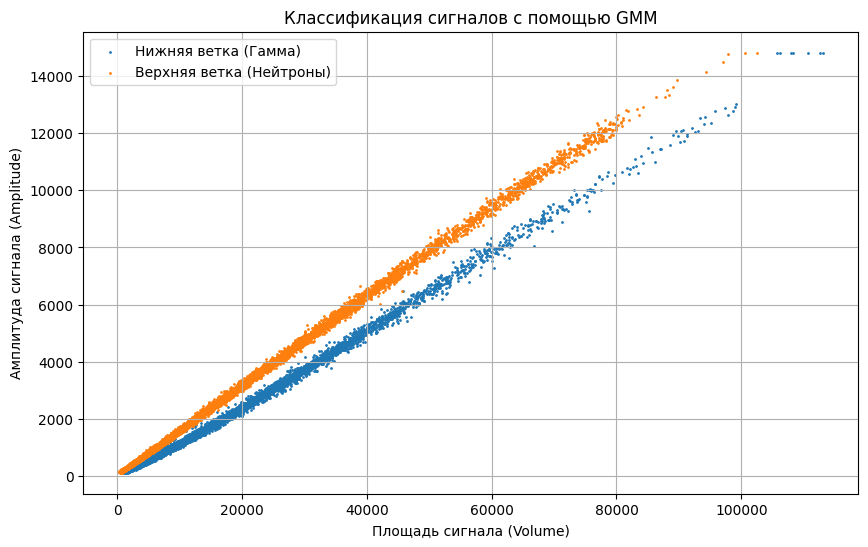

Класс 0 (Синие): 12952 шт.
Класс 1 (Оранжевые): 10527 шт.


In [ ]:
# Базовая предобработкау
baselines = np.mean(signals[:, :50], axis=1, keepdims=True)
signals_inverted = baselines - signals
amplitudes = np.max(signals_inverted, axis=1)
volumes = np.sum(signals_inverted, axis=1)
safe_volumes = np.where(volumes == 0, 1e-5, volumes)

# Формирование продвинутых геометрических признаков формы
ratio = amplitudes / safe_volumes
# Перевод в полярные координаты (угол наклона импульса и его общая мощность)
angles = np.arctan2(amplitudes, safe_volumes)
log_volumes = np.log1p(np.abs(volumes)) # Логарифм сглаживает сильный разброс по шкале X

# Сбор ризнаковой матрицы для обучения модели
features_gmm = np.column_stack((log_volumes, angles, ratio))

# Стандартизация признаки, чтобы масштабы не искажали обучение
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_gmm)

# Обучение вероятностной модели Гауссовых смесей (GMM)
# Использование параметра n_components=2
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42, max_iter=300)
final_labels = gmm.fit_predict(features_scaled)

# Автоматическое выравнивание классов (чтобы верхний хвост всегда был Классом 1)
cluster_centers = gmm.means_
if cluster_centers[0, 1] > cluster_centers[1, 1]:
    final_labels = 1 - final_labels

# Визуализация итогового результата
plt.figure(figsize=(10, 6))
plt.scatter(volumes[final_labels == 0], amplitudes[final_labels == 0], s=1, c='tab:blue', label='Нижняя ветка (Гамма)')
plt.scatter(volumes[final_labels == 1], amplitudes[final_labels == 1], s=1, c='tab:orange', label='Верхняя ветка (Нейтроны)')
plt.title("Классификация сигналов с помощью GMM")
plt.xlabel("Площадь сигнала (Volume)")
plt.ylabel("Амплитуда сигнала (Amplitude)")
plt.legend()
plt.grid(True)
plt.show()

print(f"Класс 0 (Синие): {np.sum(final_labels == 0)} шт.")
print(f"Класс 1 (Оранжевые): {np.sum(final_labels == 1)} шт.")


In [ ]:
# Создаем итоговый файл решения заново с улучшенными метками GMM
submission_df = pd.DataFrame({
    'index': range(len(final_labels)),
    'cluster': final_labels
})

submission_df.to_csv('ensemble_submission_v012.csv', index=False)
print("Файл 'ensemble_submission_v012.csv'создан")


Файл 'ensemble_submission_v012.csv'создан
